### Black-Scholes-Merton
Calculate the value of an European option

In [7]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [8]:
def bsm_option(S, K, t, sigma, rf, type='put'):
    """
    S: Underlying asset value
    K: Strike price
    t: time-span of option (annualized)
    sigma: volatility
    rf: risk-free rate (annualized)
    type: type of written option
    """
    d1 = (np.log(S / K) + (rf + 0.5 * sigma**2) * t) / sigma / np.sqrt(t)
    d2 = d1 - sigma * np.sqrt(t)
    pdf_d1 = scipy.stats.norm.pdf(d1)
    
    if type.lower() == 'put':
        cdf_d1 = scipy.stats.norm.cdf(-d1)
        cdf_d2 = scipy.stats.norm.cdf(-d2)
        value = K * np.exp(-rf * t) * cdf_d2 - S * cdf_d1
        delta = - cdf_d1
        gamma = pdf_d1 / S / sigma / np.sqrt(t)
        theta = - S * sigma * pdf_d1 / 2 / np.sqrt(t) + rf * K * np.exp(-rf * t) * cdf_d2
        vega  = S * pdf_d1 * np.sqrt(t)
        rho   = - t * K * np.exp(-rf * t) * cdf_d2
        return {
            'type': type,
            'value': value,
            'delta': delta,
            'gamma': gamma,
            'theta': theta,
            'vega' : vega,
            'rho'  : rho,
            }

    if type.lower() == 'call':
        cdf_d1 = scipy.stats.norm.cdf(d1)
        cdf_d2 = scipy.stats.norm.cdf(d2)
        value = S * cdf_d1 - K * np.exp(-rf * t) * cdf_d2
        delta = cdf_d1
        gamma = pdf_d1 / S / sigma / np.sqrt(t)
        theta = - S * sigma * pdf_d1 / 2 / np.sqrt(t) - rf * K * np.exp(-rf * t) * cdf_d2
        vega  = S * pdf_d1 * np.sqrt(t)
        rho   = t * K * np.exp(-rf * t) * cdf_d2
        return {
            'type': type,
            'value': value,
            'delta': delta,
            'gamma': gamma,
            'theta': theta,
            'vega' : vega,
            'rho'  : rho,
            }

In [9]:
S, K = 60, 60
rf = 0.08
sigma = 0.3
t = 90 / 365

bsm_option(S, K, t, sigma, rf, 'call')

{'type': 'call',
 'value': np.float64(4.1445229602782945),
 'delta': np.float64(0.5819565966075844),
 'gamma': np.float64(0.043688491714200604),
 'theta': np.float64(-9.539365484594638),
 'vega': np.float64(11.634305190740545),
 'rho': np.float64(7.587831658235366)}

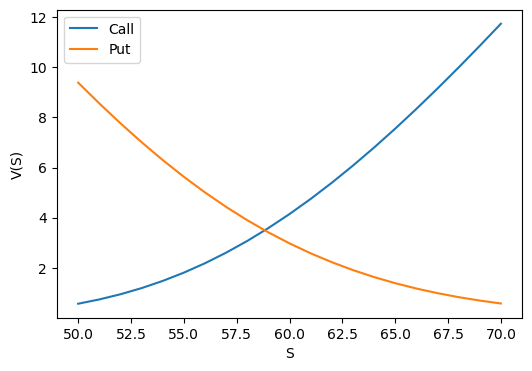

In [ ]:
# Option value change with S
stockValues = np.linspace(50, 70, 21)

K = 60
rf = 0.08
sigma = 0.3
t = 90 / 365

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(stockValues, [bsm_option(S, K, t, sigma, rf, type='call')['value'] for S in stockValues], label='Call')
ax.plot(stockValues, [bsm_option(S, K, t, sigma, rf, type='put')['value'] for S in stockValues], label='Put')
ax.set_xlabel('S')
ax.set_ylabel('V(S)')
ax.legend()
plt.show()

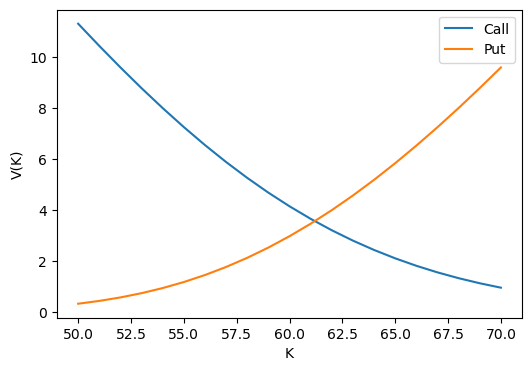

In [15]:
# Option value change with K
strikeValues = np.linspace(50, 70, 21)

S = 60
rf = 0.08
sigma = 0.3
t = 90 / 365

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(strikeValues, [bsm_option(S, K, t, sigma, rf, type='call')['value'] for K in strikeValues], label='Call')
ax.plot(strikeValues, [bsm_option(S, K, t, sigma, rf, type='put')['value'] for K in strikeValues], label='Put')
ax.set_xlabel('K')
ax.set_ylabel('V(K)')
ax.legend()
plt.show()

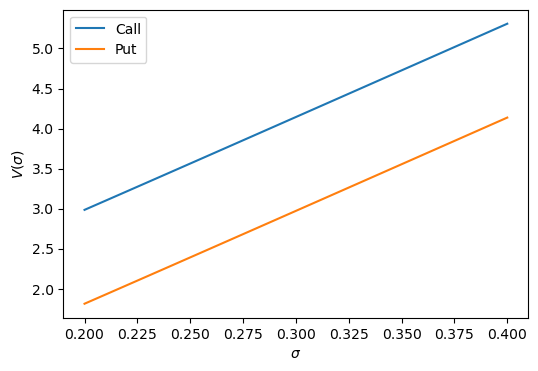

In [16]:
# Option value change with sigma
sigmaValues = np.linspace(0.2, 0.4, 21)

S = 60
K = 60
rf = 0.08
t = 90 / 365

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(sigmaValues, [bsm_option(S, K, t, sigma, rf, type='call')['value'] for sigma in sigmaValues], label='Call')
ax.plot(sigmaValues, [bsm_option(S, K, t, sigma, rf, type='put')['value'] for sigma in sigmaValues], label='Put')
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$V(\sigma)$')
ax.legend()
plt.show()

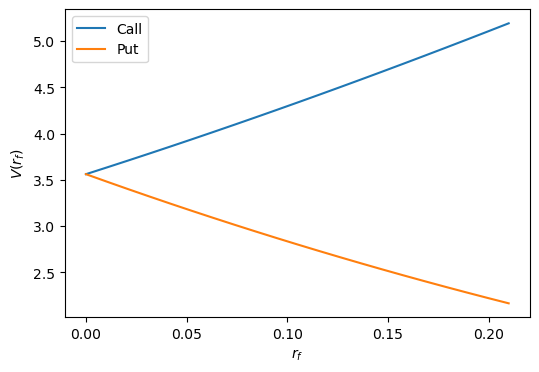

In [21]:
# Option value change with rf
rateValues = np.linspace(0.0, 0.21, 21)

S = 60
K = 60
rf = 0.08
sigma = 0.3
t = 90 / 365

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(rateValues, [bsm_option(S, K, t, sigma, rf, type='call')['value'] for rf in rateValues], label='Call')
ax.plot(rateValues, [bsm_option(S, K, t, sigma, rf, type='put')['value'] for rf in rateValues], label='Put')
ax.set_xlabel(r'$r_f$')
ax.set_ylabel(r'$V(r_f)$')
ax.legend()
plt.show()

/tmp/ipykernel_52162/506499129.py:10: RuntimeWarning: invalid value encountered in scalar divide
  d1 = (np.log(S / K) + (rf + 0.5 * sigma**2) * t) / sigma / np.sqrt(t)


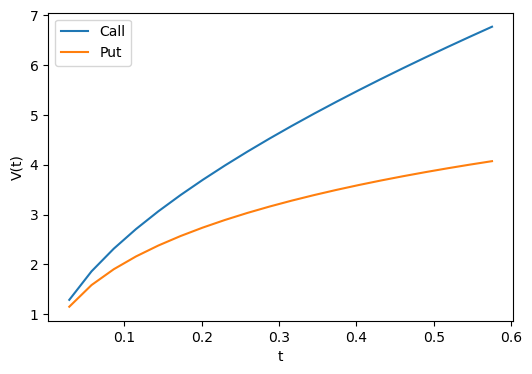

In [19]:
# Option value change with t
timeValues = np.linspace(0, 210, 21) /365

S = 60
K = 60
rf = 0.08
sigma = 0.3

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(timeValues, [bsm_option(S, K, t, sigma, rf, type='call')['value'] for t in timeValues], label='Call')
ax.plot(timeValues, [bsm_option(S, K, t, sigma, rf, type='put')['value'] for t in timeValues], label='Put')
ax.set_xlabel('t')
ax.set_ylabel('V(t)')
ax.legend()
plt.show()

In [5]:
S, K = 59, 60
rf = 0.08
sigma = 0.3
t = 89 / 365

bsm_option(S, K, t, sigma, rf, 'call')

{'type': 'call',
 'value': np.float64(3.5590685665416792),
 'delta': np.float64(0.5367677180045403),
 'gamma': np.float64(0.04545048626779061),
 'theta': np.float64(-9.368409565076156),
 'vega': np.float64(11.573399753538034),
 'rho': np.float64(6.854274478957894)}

In [6]:
S, K = 1.82, 1.80
rf = 0.05
sigma = 0.14
t = 90 / 365

bsm_option(S, K, t, sigma, rf, 'put')

{'type': 'put',
 'value': np.float64(0.03164802147710799),
 'delta': np.float64(-0.35529984655128166),
 'gamma': np.float64(2.943332122543911),
 'theta': np.float64(-0.061630347452579615),
 'vega': np.float64(0.3365578516882249),
 'rho': np.float64(-0.1672505117754511)}

In [7]:
S, K = 1.81, 1.80
rf = 0.05
sigma = 0.14
t = 89 / 365

bsm_option(S, K, t, sigma, rf, 'put')

{'type': 'put',
 'value': np.float64(0.035182180376205796),
 'delta': np.float64(-0.38550212488277147),
 'gamma': np.float64(3.0560387716466875),
 'theta': np.float64(-0.061469457153257696),
 'vega': np.float64(0.3417757046646706),
 'rho': np.float64(-0.17871712698862458)}

In [8]:
S, K = 60, 60
rf = 0.08
sigma = 0.30
t = 90 / 365

bsm_option(S, K, t, sigma, rf, 'call')

{'type': 'call',
 'value': np.float64(4.1445229602782945),
 'delta': np.float64(0.5819565966075844),
 'gamma': np.float64(0.043688491714200604),
 'theta': np.float64(-9.539365484594638),
 'vega': np.float64(11.634305190740545),
 'rho': np.float64(7.587831658235366)}

In [9]:
S, K = 60, 65
rf = 0.08
sigma = 0.30
t = 60 / 365

bsm_option(S, K, t, sigma, rf, 'call')

{'type': 'call',
 'value': np.float64(1.3782577171980002),
 'delta': np.float64(0.3123732423647997),
 'gamma': np.float64(0.04850151859857283),
 'theta': np.float64(-9.246376958943998),
 'vega': np.float64(8.610680562157588),
 'rho': np.float64(2.854378656113422)}